In [ ]:
import os
import pathlib
import pandas as pd

from paths import experiment_folders_val
from analysis_utils import get_aggregated_dataframe

plot_output_folder = "val_results_plots"
os.makedirs(plot_output_folder, exist_ok=True)

FEW_SHOT_IDX = [19715,18571,20194] # exclude few-shot experiments from validation set analysis, since they have been "seen" by some models during inference

df_results = get_aggregated_dataframe(experiment_folders_val, exclude_idxs=FEW_SHOT_IDX, subset="val")


In [ ]:
top_dfs = []
for model in df_results["model_name"].unique():
    top_df = df_results[df_results["model_name"] == model].sort_values(by="f1_score", ascending=False).head(3)
    top_dfs.append(top_df)
top_df = pd.concat(top_dfs)

# save as csv
top_df.groupby("model_name").agg({"f1_score": "mean"}).reset_index().to_csv("top_results_per_model_val.csv", index=False)


top_df_models = top_df.groupby("model_name")["f1_score"].mean().sort_values(ascending=False).head(5).index.tolist()
print(f"Top 5 models by mean f1_score: {top_df_models}")
    
top_df_reduced = top_df[top_df["model_name"].isin(top_df_models)]
top_df_reduced[["model_name", "System Prompt", "User Prompt", "f1_score", "kappa","accuracy"]].to_csv("selected_models_prompts_val.csv", index=False)


experiment_folders_best = top_df_reduced["experiment_folder"].tolist()

# create a dict where the model name is the key and the value is the list of (system_prompt, user_prompt) tuples for the best experiments
best_experiments_dict = {}
for index, row in top_df_reduced.iterrows():
    model_name = row["model_name"]
    system_prompt = row["System Prompt"]
    user_prompt = row["User Prompt"]
    
    if model_name not in best_experiments_dict:
        best_experiments_dict[model_name] = []
    
    best_experiments_dict[model_name].append((system_prompt, user_prompt))
print("Best experiments dict:", best_experiments_dict)
    
top_df_reduced

Top 5 models by mean f1_score: ['microsoft/phi-4', 'mistralai/Ministral-3-14B-Instruct-2512', 'google/gemma-3-27b-it', 'mistralai/Mistral-Small-3.2-24B-Instruct-2506', 'Qwen/Qwen3-30B-A3B-Instruct-2507']
Best experiments dict: {'Qwen/Qwen3-30B-A3B-Instruct-2507': [('SP2', 'UP1-FS'), ('SP5', 'UP2'), ('SP5', 'UP3')], 'mistralai/Mistral-Small-3.2-24B-Instruct-2506': [('SP3', 'UP1-FS'), ('SP5', 'UP2'), ('SP4', 'UP1')], 'mistralai/Ministral-3-14B-Instruct-2512': [('SP4', 'UP3'), ('SP3', 'UP2'), ('SP5', 'UP2')], 'google/gemma-3-27b-it': [('SP4', 'UP1'), ('SP3', 'UP1'), ('SP4', 'UP1-FS')], 'microsoft/phi-4': [('SP4', 'UP2'), ('SP3', 'UP2'), ('SP4', 'UP4')]}


,experiment_folder,max_new_tokens,System Prompt,User Prompt,model_name,num_params,config_path,temperature,subset,f1_score,kappa,accuracy
517,Qwen3-30B-A3B-Instruct-2507_SP2_UP1-FS,100000.0,SP2,UP1-FS,Qwen/Qwen3-30B-A3B-Instruct-2507,30.0,experiment_configs/ACLW_val.yml,0,all,0.851416,0.788093,0.871429
164,Qwen3-30B-A3B-Instruct-2507_SP5_UP2,100000.0,SP5,UP2,Qwen/Qwen3-30B-A3B-Instruct-2507,30.0,experiment_configs/ACLW_val.yml,0,all,0.836111,0.778947,0.871429
163,Qwen3-30B-A3B-Instruct-2507_SP5_UP3,100000.0,SP5,UP3,Qwen/Qwen3-30B-A3B-Instruct-2507,30.0,experiment_configs/ACLW_val.yml,0,all,0.824822,0.779489,0.871429
357,Mistral-Small-3.2-24B-Instruct-2506_SP3_UP1-FS,100000.0,SP3,UP1-FS,mistralai/Mistral-Small-3.2-24B-Instruct-2506,24.0,experiment_configs/ACLW_val.yml,0,all,0.856308,0.789227,0.871429
301,Mistral-Small-3.2-24B-Instruct-2506_SP5_UP2,100000.0,SP5,UP2,mistralai/Mistral-Small-3.2-24B-Instruct-2506,24.0,experiment_configs/ACLW_val.yml,0,all,0.841762,0.788235,0.871429
173,Mistral-Small-3.2-24B-Instruct-2506_SP4_UP1,100000.0,SP4,UP1,mistralai/Mistral-Small-3.2-24B-Instruct-2506,24.0,experiment_configs/ACLW_val.yml,0,all,0.819520,0.743333,0.842857
119,Ministral-3-14B-Instruct-2512_SP4_UP3,100000.0,SP4,UP3,mistralai/Ministral-3-14B-Instruct-2512,14.0,experiment_configs/ACLW_val.yml,0,all,0.865915,0.779489,0.871429
352,Ministral-3-14B-Instruct-2512_SP3_UP2,100000.0,SP3,UP2,mistralai/Ministral-3-14B-Instruct-2512,14.0,experiment_configs/ACLW_val.yml,0,all,0.859501,0.788093,0.871429
334,Ministral-3-14B-Instruct-2512_SP5_UP2,100000.0,SP5,UP2,mistralai/Ministral-3-14B-Instruct-2512,14.0,experiment_configs/ACLW_val.yml,0,all,0.826874,0.757282,0.857143
132,gemma-3-27b-it_SP4_UP1,100000.0,SP4,UP1,google/gemma-3-27b-it,27.0,experiment_configs/ACLW_val.yml,0,all,0.875000,0.825871,0.900000


In [ ]:
df_results[["model_name", "num_params","System Prompt", "User Prompt", "temperature", "f1_score","kappa"]][:30]

,model_name,num_params,System Prompt,User Prompt,temperature,f1_score,kappa
0,microsoft/Phi-4-mini-instruct,4.0,SP0,UP1-FS,0,0.358689,0.107363
1,meta-llama/Llama-3.1-8B-Instruct,8.0,SP1,UP4,0,0.627652,0.478779
2,microsoft/Phi-4-mini-instruct,4.0,SP1,UP4,0,0.436075,0.202984
3,Qwen/Qwen2.5-32B-Instruct,32.0,SP2,UP3,0,0.830009,0.727915
4,microsoft/Phi-4-mini-instruct,4.0,SP2,UP1,0,0.263007,0.036973
5,google/gemma-3-4b-it,4.0,SP2,UP3,0,0.556118,0.445983
6,ibm-granite/granite-4.0-micro,3.0,SP4,UP2,0,0.571390,0.384164
7,Qwen/Qwen2.5-14B-Instruct,14.0,SP1,UP3,0,0.646671,0.526494
8,Qwen/Qwen3-4B-Instruct-2507,4.0,SP4,UP1,0,0.768168,0.664269
9,meta-llama/Llama-3.2-3B-Instruct,3.0,SP2,UP1-FS,0,0.158507,0.015345


/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 12 x 14 in image.
/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: val_results_plots/f1_scores_by_model_and_prompt_variant.pdf


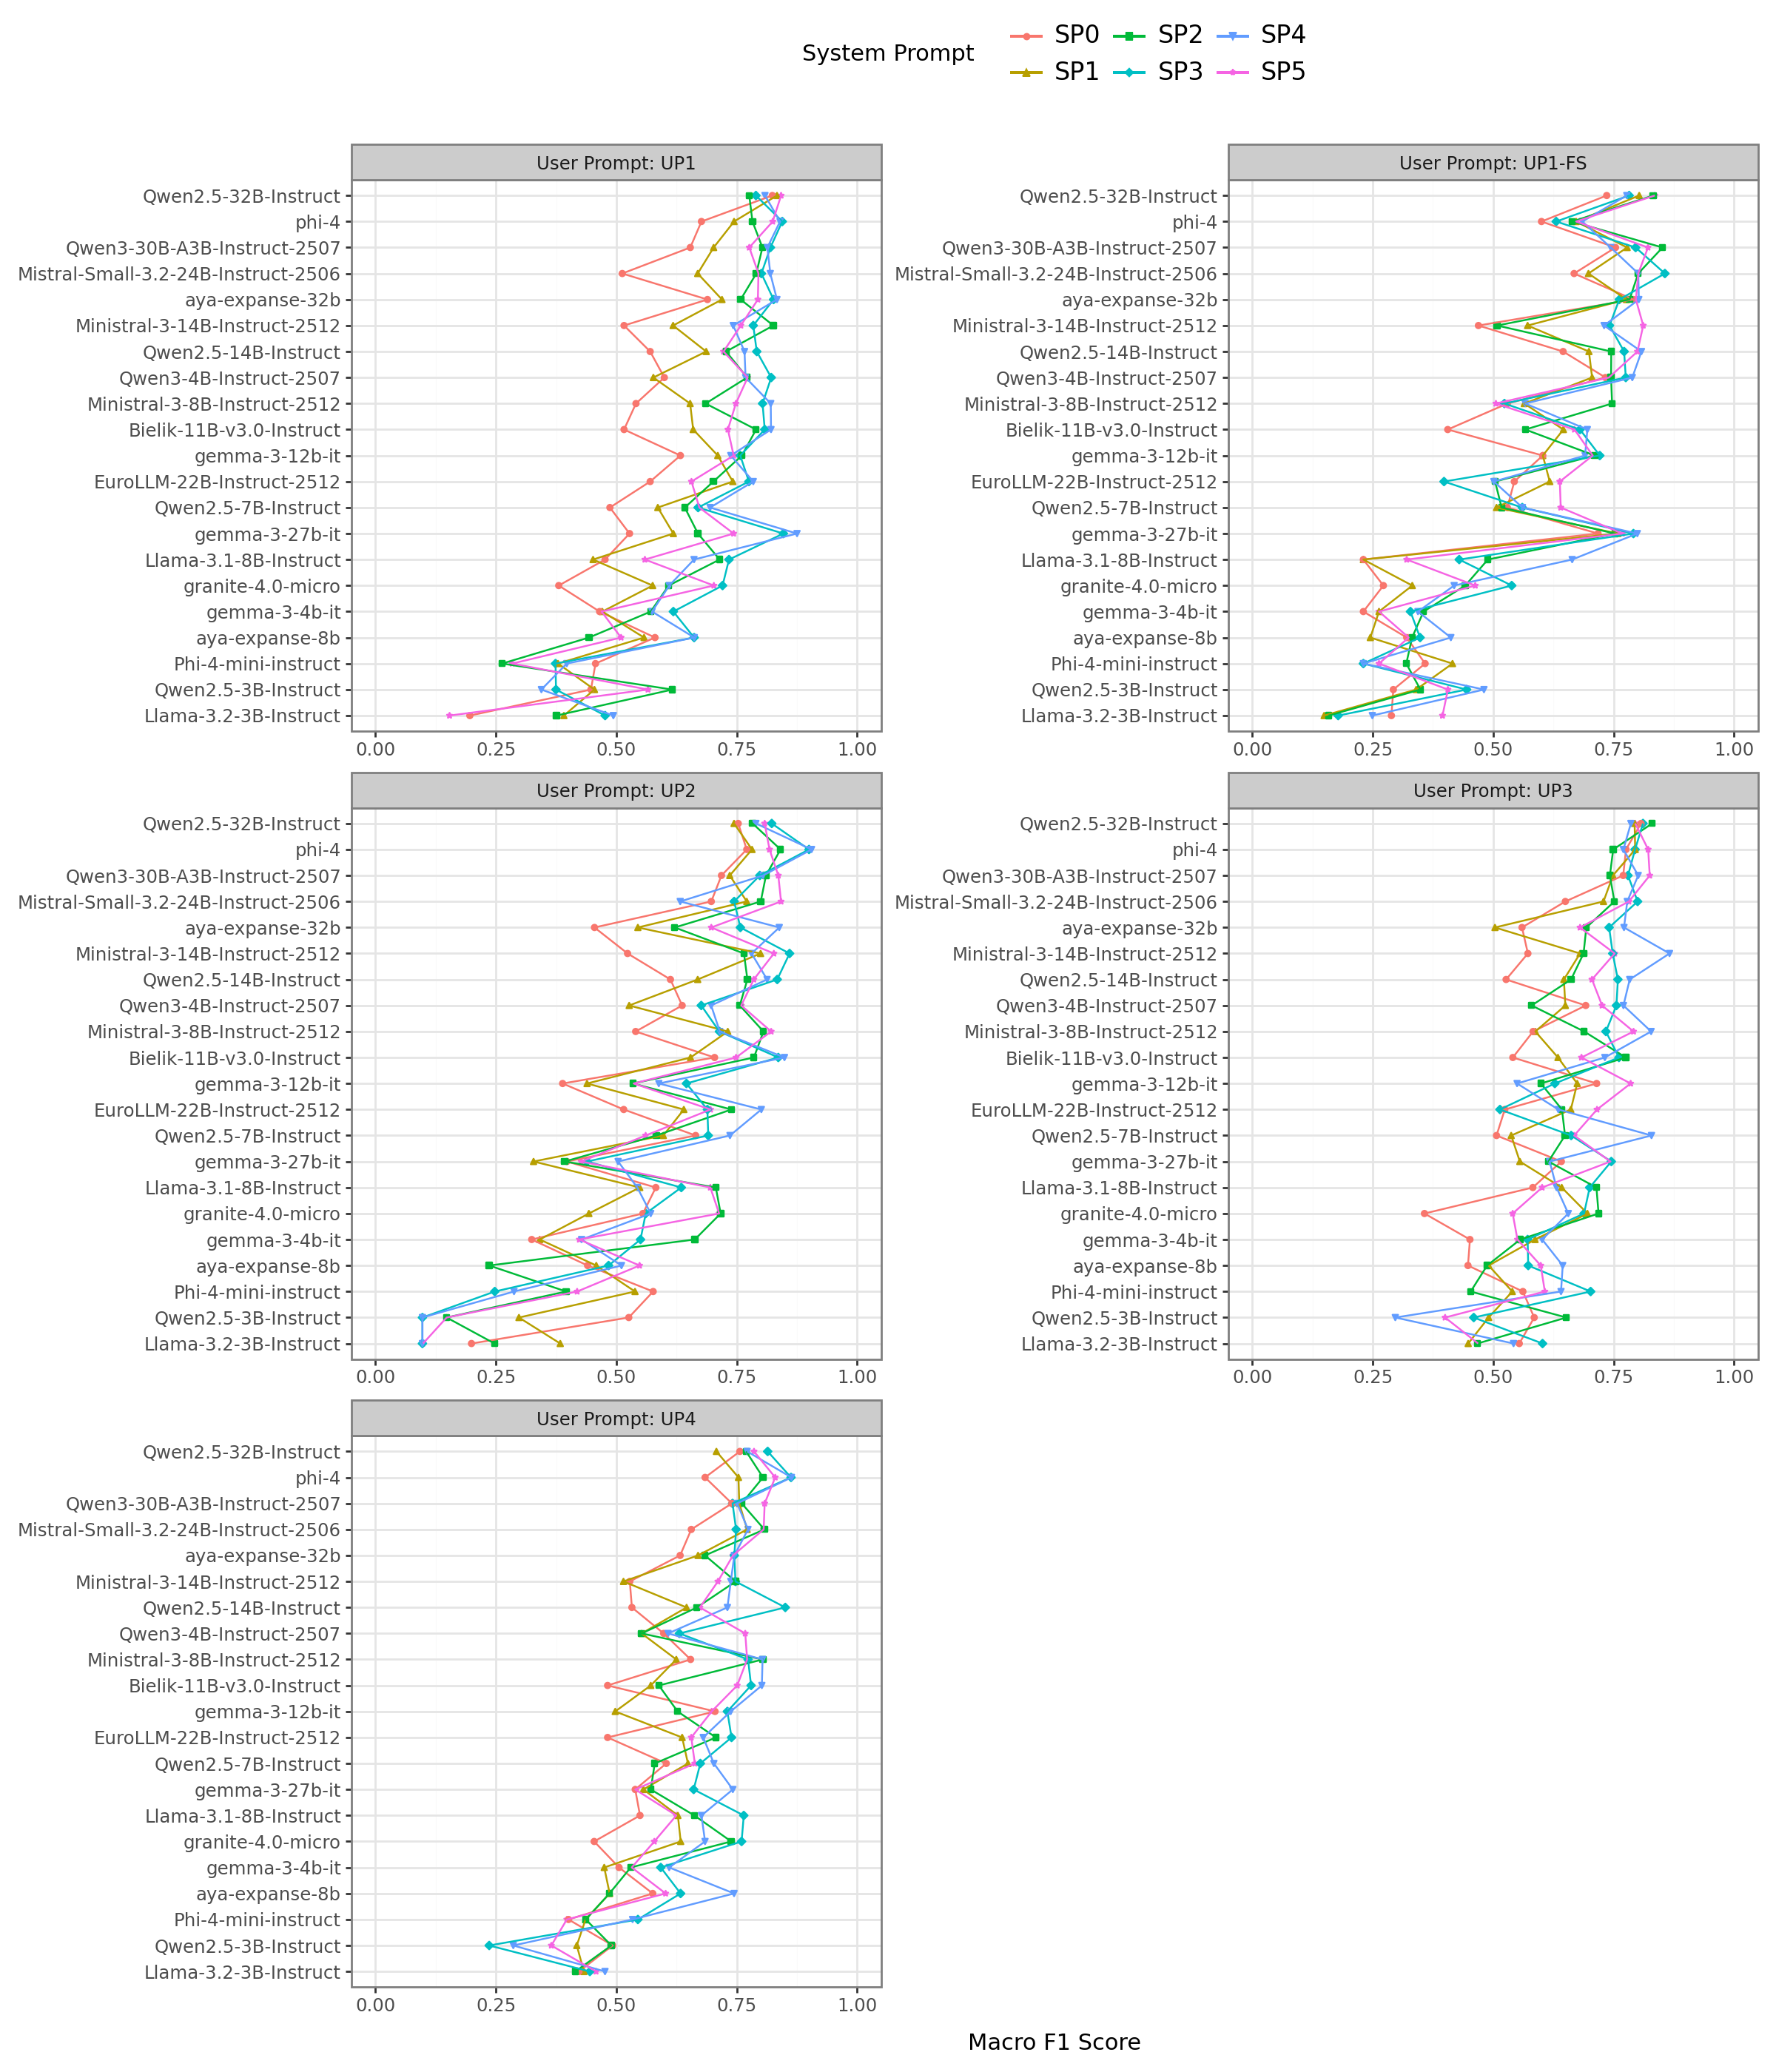

In [ ]:
import plotnine as p9

# create thhe folder val_results_plots if it does not exist
pathlib.Path(f"{plot_output_folder }").mkdir(exist_ok=True)

df_results_plot = df_results.copy()

df_results_plot["model_name_short"] = df_results_plot["model_name"].apply(lambda x: x.split("/")[-1])

# create a bar plot of f1 scores for each model and prompt variant
plot = (p9.ggplot(df_results_plot, p9.aes(x="reorder(model_name_short, f1_score)", y="f1_score", fill="System Prompt", color="System Prompt"))
 + p9.geom_point(p9.aes(shape="System Prompt"), size=1)
 + p9.geom_line(p9.aes(group="System Prompt"))
 + p9.facet_wrap("User Prompt",ncol=2, labeller="label_both", scales="free")
 + p9.ylim(0, 1)
 + p9.xlab("")
 + p9.ylab("Macro F1 Score")
 + p9.coord_flip()
 + p9.theme_bw()
 + p9.theme(figure_size=(12,14), legend_position="top", legend_margin=0.0, legend_text=p9.element_text(size=12))
)
plot.save(f"{plot_output_folder }/f1_scores_by_model_and_prompt_variant.pdf", dpi=300)
plot.show()



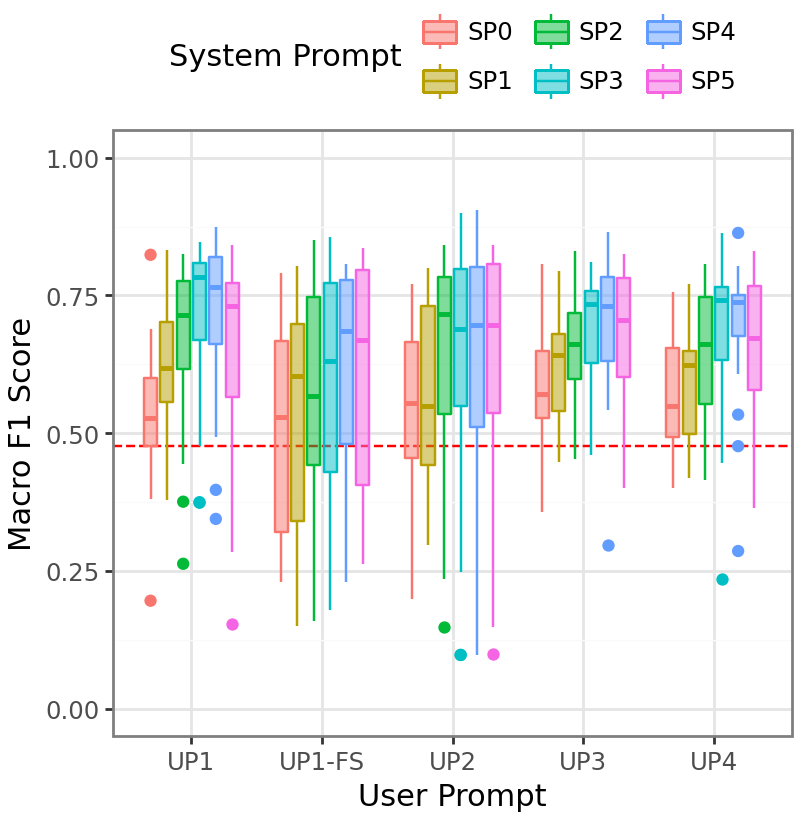

/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 4 x 4.1 in image.
/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: val_results_plots/f1_scores_by_user_prompt_and_system_prompt.pdf
/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 4 x 4.1 in image.
/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: val_results_plots/f1_scores_by_user_prompt_and_system_prompt.png


In [ ]:
plot = (p9.ggplot(df_results_plot, p9.aes(x="User Prompt", y="f1_score", fill="System Prompt", color="System Prompt"))
 + p9.geom_hline(yintercept=0.4765, linetype="dashed", color="red")
 + p9.geom_boxplot(width=0.6, alpha=0.5, position=p9.position_dodge(width=0.75))
 + p9.ylim(0, 1)
 
 + p9.xlab("User Prompt")
 + p9.ylab("Macro F1 Score")

 + p9.theme_bw()
 + p9.theme(figure_size=(4,4.1), legend_position="top", legend_margin=0.0)
)
plot.show()
plot.save(f"{plot_output_folder }/f1_scores_by_user_prompt_and_system_prompt.pdf", dpi=300)
plot.save(f"{plot_output_folder }/f1_scores_by_user_prompt_and_system_prompt.png", dpi=300)


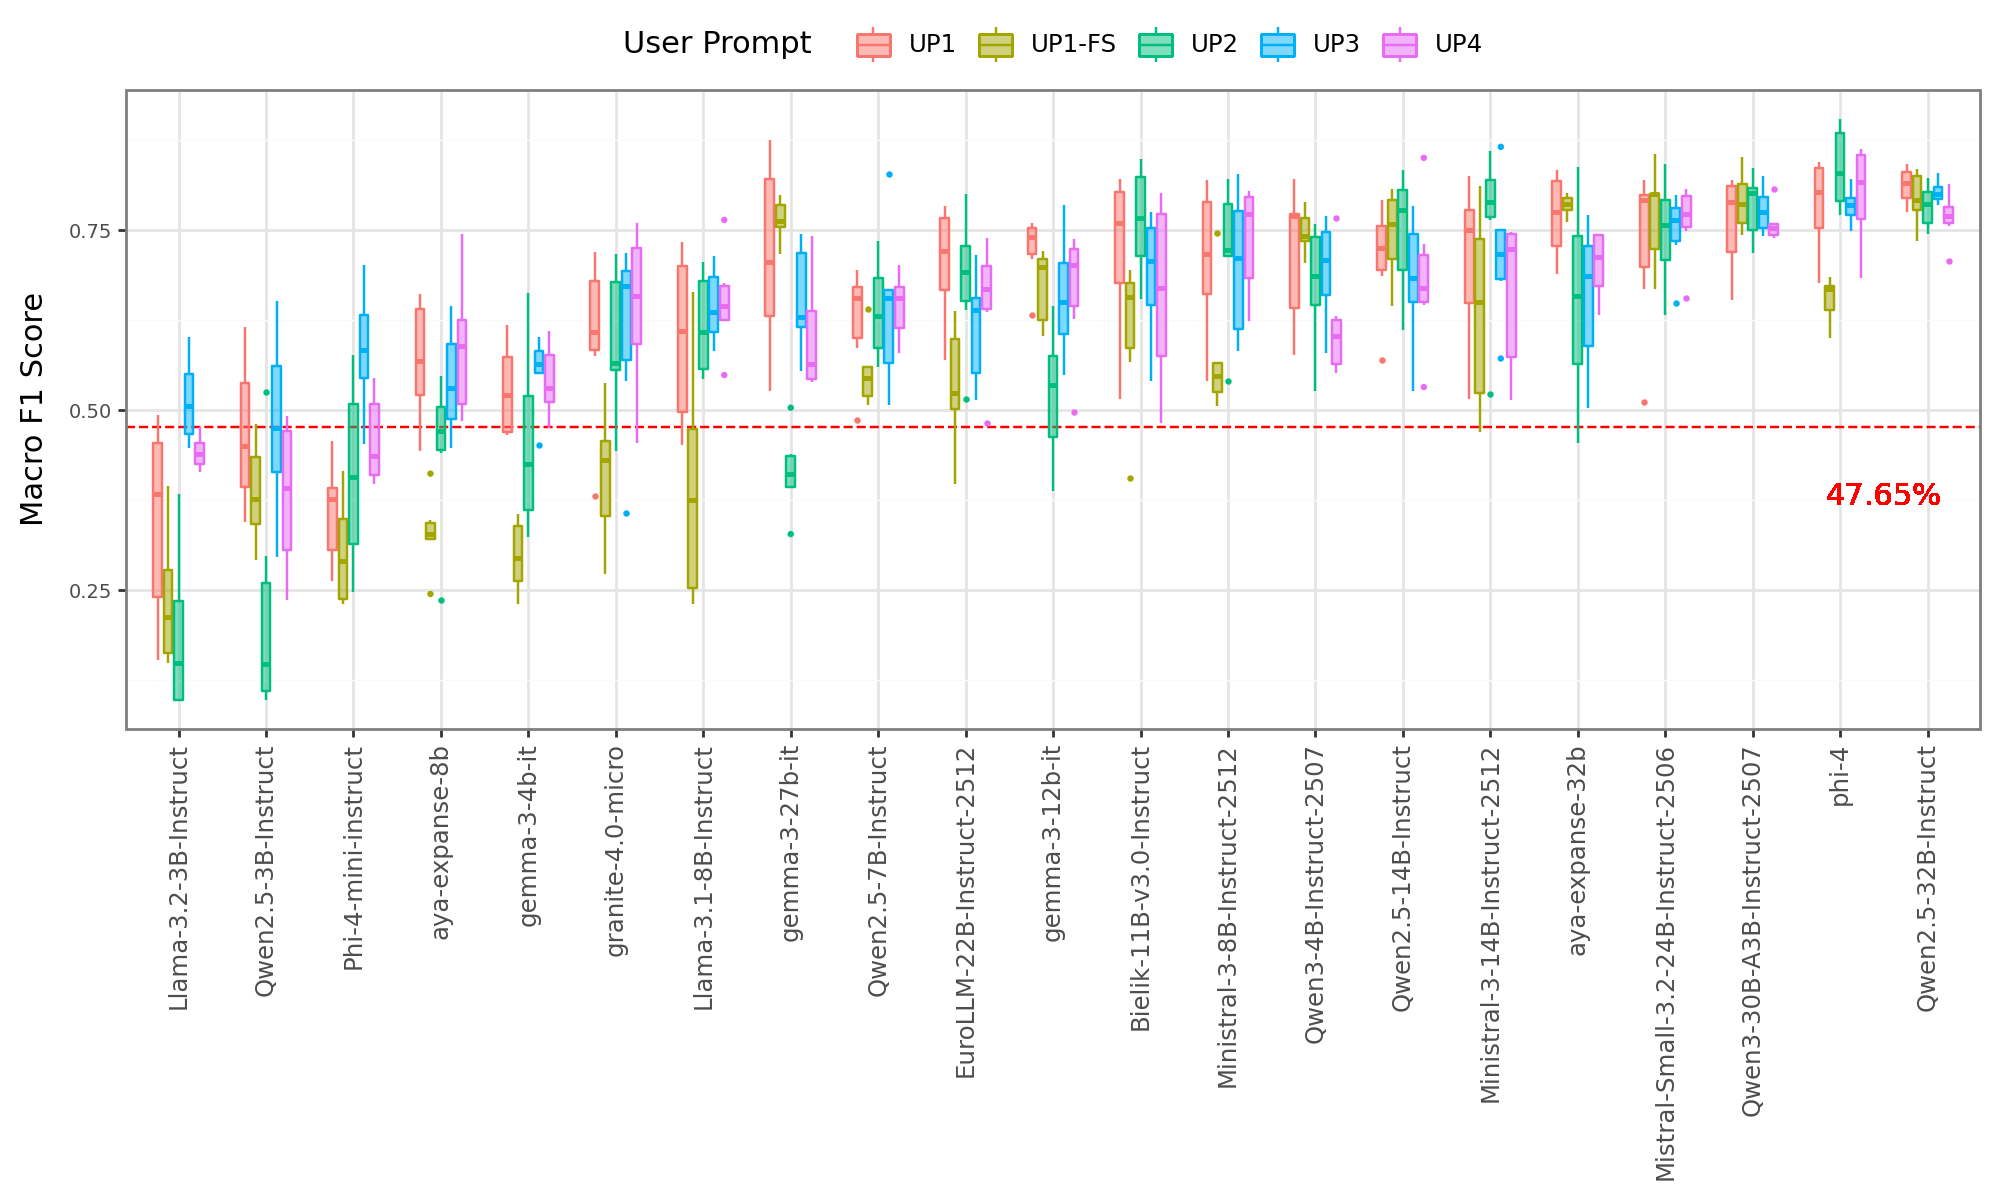

/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 10 x 6 in image.
/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: val_results_plots/f1_scores_by_model_and_user_prompt_horiz.pdf


In [ ]:

# create boxplot of f1 scores for each model and prompt variant
plot = (p9.ggplot(df_results_plot, p9.aes(x="reorder(model_name_short, f1_score)", y="f1_score", fill="User Prompt", color="User Prompt"))
 + p9.geom_hline(yintercept=0.4765, linetype="dashed", color="red")
 + p9.geom_text(y=0.38, x=20.5, color="red", label="47.65%", raster=True)
 + p9.geom_boxplot(width=0.5, alpha=0.5, position=p9.position_dodge(width=0.6), outlier_size=0.3)
 + p9.ylab("Macro F1 Score")
  + p9.theme_bw()
 + p9.theme(figure_size=(10,6), legend_position="top", legend_margin=0.0)
 + p9.guides(fill=p9.guide_legend(nrow=1, title="User Prompt"))
 + p9.theme(axis_text_y=p9.element_text(size=7),axis_text_x=p9.element_text(rotation=90), legend_box_spacing=0.01)
 + p9.xlab("")
)
plot.show()
plot.save(f"{plot_output_folder }/f1_scores_by_model_and_user_prompt_horiz.pdf", dpi=300)

/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/scales/scales.py:48: PlotnineWarning: Scale for 'x' is already present.
Adding another scale for 'x',
which will replace the existing scale.

/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6 x 6 in image.
/media/gala/1d738d7f-e330-40e9-831d-8b58976c4bf9/GALA/RAB-Cred-ACLW_paper_priv/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: val_results_plots/f1_scores_by_model_size.pdf


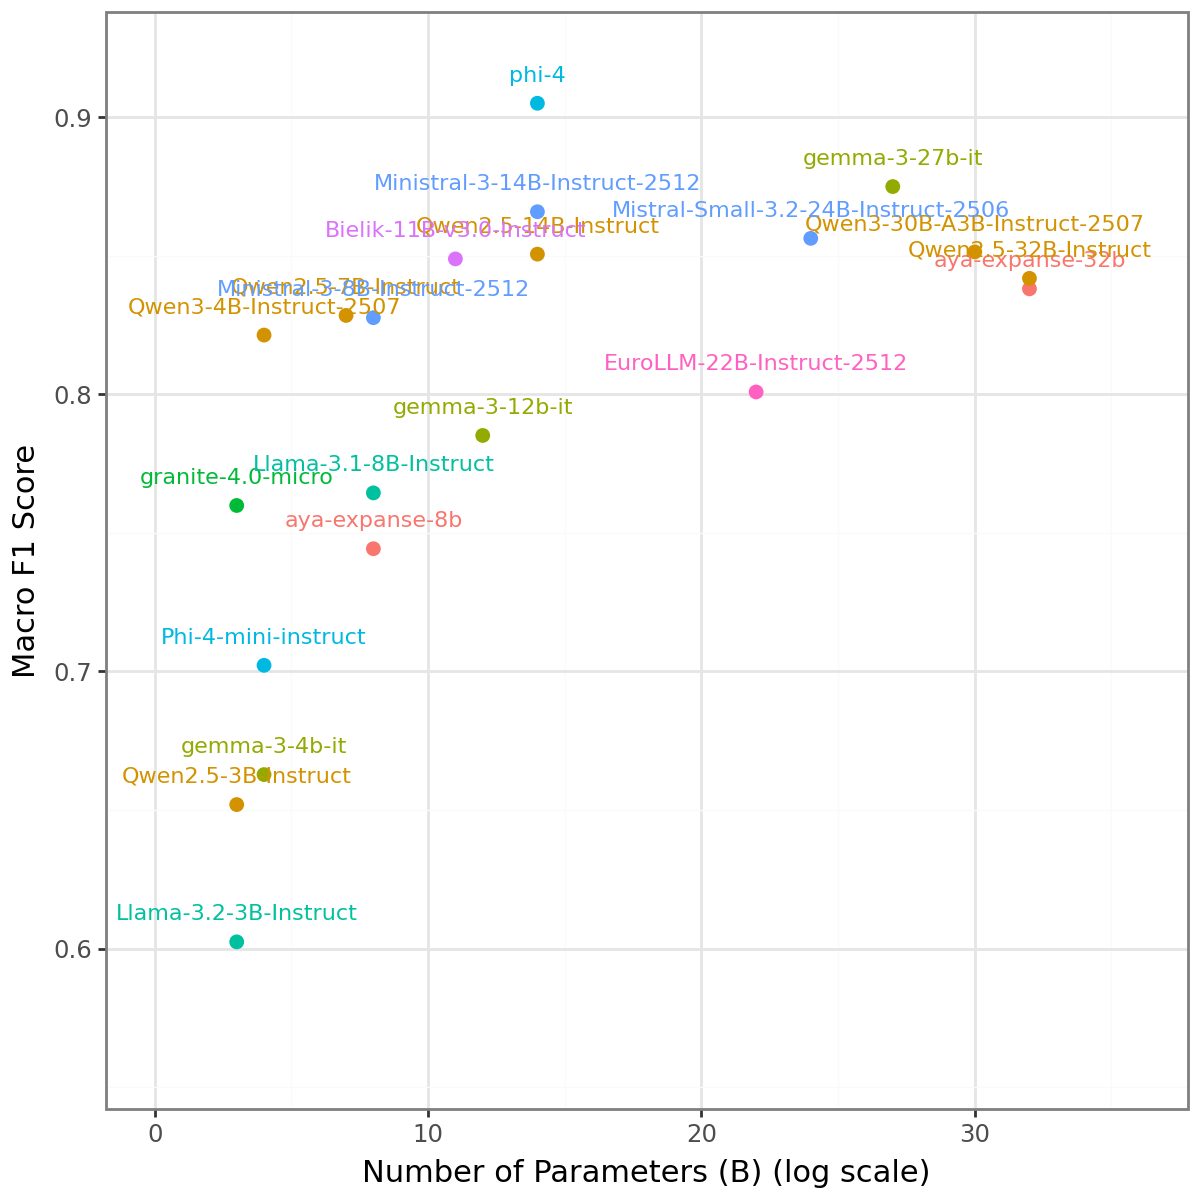

In [ ]:
# get average performance per model across all prompt variants
df_results_agg = df_results.groupby(["model_name", "num_params"]).agg({"f1_score": "max"}).reset_index()
df_results_agg["model_variant"] = df_results_agg["model_name"].apply(lambda x: x.split("/")[-1])
df_results_agg["model_family"] = df_results_agg["model_name"].apply(lambda x: x.split("/")[0])

plot = (p9.ggplot(df_results_agg, p9.aes(x="num_params", y="f1_score", color="model_family"))
 + p9.geom_point(size=2)
 + p9.scale_x_log10()
 + p9.geom_text(p9.aes(label="model_variant"), size=8, nudge_y=0.01)
 + p9.ylim(0.56, 0.92)
 + p9.xlim(0,36)
 + p9.xlab("Number of Parameters (B) (log scale)")
 + p9.ylab("Macro F1 Score")
 + p9.theme_bw()
 + p9.theme(figure_size=(6,6), legend_position="top", legend_margin=0.0)
 + p9.theme(legend_title=p9.element_blank())
+ p9.theme(legend_position="none")
)
plot.save(f"{plot_output_folder }/f1_scores_by_model_size.pdf", dpi=300)
plot.show()